In [12]:
#!/usr/bin/env python3 
# mmca_init_eta_single_graph_save.py
"""
Run MMCA on one random 3-uniform hypergraph and save time series CSVs
for the specified (init_frac, eta) parameter pairs.

Outputs:
  out_dir/init{init:.2f}_eta{eta:.2f}.csv
Each CSV has columns: time, rho, theta_mean, phi_median
"""

import os
import time
import numpy as np
import random
import pandas as pd

# --------------------- hypergraph generator ---------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    """Generate a random 3-uniform hypergraph as ndarray shape (m,3)."""
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random
    d = 3
    m = int(round(n * kappa / d))
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# --------------------- MMCA model (unchanged) ---------------------
class HyperSISMMCA:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0]; self.edge_j = self.hyperedges[:,1]; self.edge_k = self.hyperedges[:,2]
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def mmca_step(self, p, Theta, beta_d, mu, eta, gamma):
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        Q = np.ones(self.n)
        for node in range(self.n):
            pv = 1.0
            for (ei,pos) in self.node_edge_pos[node]:
                if pos == 0:
                    oth = prod_pos0[ei]
                elif pos == 1:
                    oth = prod_pos1[ei]
                else:
                    oth = prod_pos2[ei]
                pv *= (1.0 - Theta[ei] * beta_d * oth)
            Q[node] = pv
        p_next = (1 - p) * (1 - Q) + (1 - mu) * p
        # update Theta
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_next = Theta * (1 - eta * Phi) + gamma * (1 - Theta)
        return p_next, np.clip(Theta_next, 0, 1), Phi

    def run_mmca(self, beta_d, mu, eta, gamma, T, init_frac):
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)
        rho_t, theta_t, phi_t = [], [], []
        for t in range(T):
            rho_t.append(p.mean())
            theta_t.append(Theta.mean())
            p, Theta, Phi = self.mmca_step(p, Theta, beta_d, mu, eta, gamma)
            # store a summary stat for Phi (median is robust to outliers)
            phi_t.append(np.median(Phi))
        return np.array(rho_t), np.array(theta_t), np.array(phi_t)

# --------------------- save helper ---------------------
def save_csv(out_dir, init_frac, eta, t, rho, theta, phi):
    fn = os.path.join(out_dir, f"init{init_frac:.2f}_eta{eta:.2f}.csv")
    df = pd.DataFrame({'time': t, 'rho': rho, 'theta_mean': theta, 'phi_median': phi})
    df.to_csv(fn, index=False, float_format="%.6f")
    return fn

# --------------------- Parameters (edit here) ---------------------
n = 1500
kappa = 6.0
beta = 0.20
mu = 0.1
gamma = 0.02
T = 1000
seed = 12345   # seed for hypergraph generation; set None for non-deterministic

# the four (init, eta) combos you asked for:
param_pairs = [
    (0.20, 0.6),
    (0.20, 0.8),
    (0.80, 0.6),
    (0.80, 0.8)
]

out_dir = "mmca_init_eta_repeat_out"   # same folder your plotting script expects
os.makedirs(out_dir, exist_ok=True)

# --------------------- Run on one hypergraph and save CSVs ---------------------
num_repeats = 30  # 重复次数

for (init_frac, eta) in param_pairs:
    print(f"Running MMCA for init={init_frac}, eta={eta} ...")
    
    # 创建二维数组存储每次重复的结果
    rho_all = np.zeros((num_repeats, T))
    theta_all = np.zeros((num_repeats, T))
    phi_all = np.zeros((num_repeats, T))

    for rep in range(num_repeats):
        # 每次生成新的超图（或使用同一张超图）
        hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=None, batch_size=3000)
        model = HyperSISMMCA(hyperedges, n)
        
        rho, theta, phi = model.run_mmca(beta_d=beta, mu=mu, eta=eta, gamma=gamma, T=T, init_frac=init_frac)
        
        # 存入二维数组
        rho_all[rep] = rho
        theta_all[rep] = theta
        phi_all[rep] = phi

    # 用mean()求平均（沿重复轴）
    rho_avg = rho_all.mean(axis=0)
    theta_avg = theta_all.mean(axis=0)
    phi_avg = phi_all.mean(axis=0)

    # 保存平均结果
    fn = os.path.join(out_dir, f"init{init_frac:.2f}_eta{eta:.2f}_avg.csv")
    t_arr = np.arange(T)
    df = pd.DataFrame({'time': t_arr, 'rho': rho_avg, 'theta_mean': theta_avg, 'phi_median': phi_avg})
    df.to_csv(fn, index=False, float_format="%.6f")
    print(f" saved -> {fn}")

print("All done. Four average CSVs are in:", out_dir)


Running MMCA for init=0.2, eta=0.6 ...
 saved -> mmca_init_eta_repeat_out\init0.20_eta0.60_avg.csv
Running MMCA for init=0.2, eta=0.8 ...
 saved -> mmca_init_eta_repeat_out\init0.20_eta0.80_avg.csv
Running MMCA for init=0.8, eta=0.6 ...
 saved -> mmca_init_eta_repeat_out\init0.80_eta0.60_avg.csv
Running MMCA for init=0.8, eta=0.8 ...
 saved -> mmca_init_eta_repeat_out\init0.80_eta0.80_avg.csv
All done. Four average CSVs are in: mmca_init_eta_repeat_out


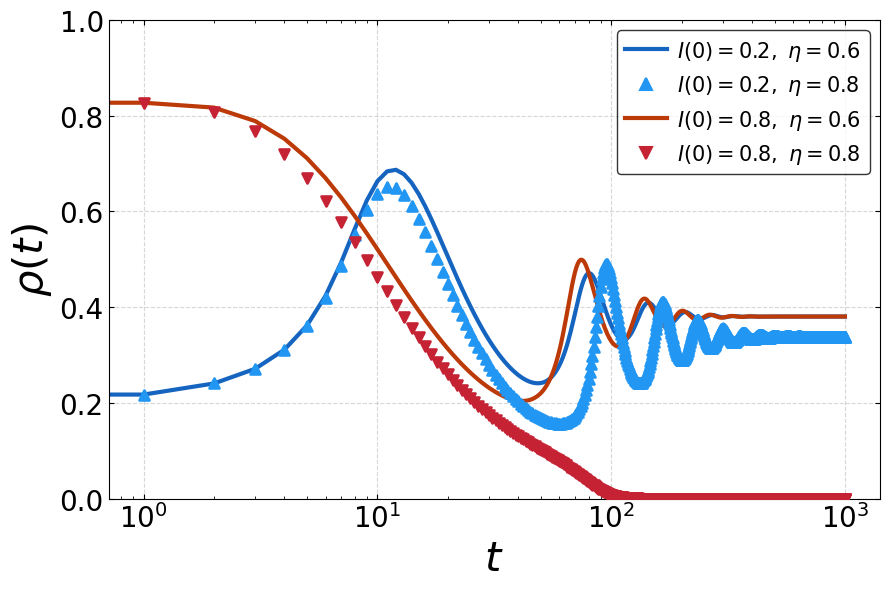

In [1]:
#!/usr/bin/env python3
# plot_mmca_init_eta_curves.py

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ===================== User Config =====================
DATA_DIR = "mmca_init_eta_repeat_out"

# 所有数据对
pairs = [
    (0.20, 0.60),  # 直线1
    (0.20, 0.80),  # 散点1
    (0.80, 0.60),  # 直线2
    (0.80, 0.80)   # 散点2
]

# 颜色配置
colors = ['#1565c0', '#2196f3', '#bc3908', '#c52233']

# 标签配置
labels = [fr'$I(0)={i}, \  \eta={e}$' for (i,e) in pairs]

# 样式配置：交替使用直线和散点
plot_types = ['line', 'scatter', 'line', 'scatter']  # 定义每条线的类型
linestyles = ['-', '', '-', '']  # 散点图不需要线型
markers = ['', '^', '', 'v']     # 直线不需要标记，散点需要
# ========================================================

# ---------- Load data ----------
dfs = []
for (init, eta) in pairs:
    fn = os.path.join(DATA_DIR, f"init{init:.2f}_eta{eta:.2f}_avg.csv")
    df = pd.read_csv(fn)
    dfs.append(df)

# ---------- Plot rho(t) ----------
plt.figure(figsize=(9,6))

# 存储图例句柄和标签
legend_handles = []
legend_labels = []

# 按顺序绘制所有曲线
for i, (df, lab, col, plot_type, ls, marker) in enumerate(zip(dfs, labels, colors, plot_types, linestyles, markers)):
    time = df["time"].values
    rho = df["rho"].values
    
    # 创建自定义索引
    # idx_before_100 = np.where(time <= 100)[0]
    # idx_after_100 = np.where(time > 100)[0]
    # if len(idx_after_100) > 0:
    #     idx_after_100_sampled = idx_after_100[::15]
    #     if len(idx_after_100_sampled) == 0:
    #         idx_after_100_sampled = [idx_after_100[-1]]
    # else:
    #     idx_after_100_sampled = []
    
    # indices = list(idx_before_100) + list(idx_after_100_sampled)
    
    if plot_type == 'line':
        # 绘制线条
        line = plt.plot(time, rho, 
                       linestyle=ls, 
                       label=lab, 
                       linewidth=3, 
                       color=col)[0]
        legend_handles.append(line)
        
    else:  # scatter
        # 绘制散点
        scatter = plt.scatter(#time[indices], rho[indices],
                             time, rho,
                             marker=marker,
                             s=50,
                             facecolor=col,
                             edgecolor=col,
                             linewidth=2,
                             label=lab,
                             zorder=3)
        # 创建散点的图例句柄
        scatter_handle = Line2D([0], [0], 
                               marker=marker, 
                               color='w', 
                               markerfacecolor=col,
                               markeredgecolor=col,
                               markersize=8,
                               markeredgewidth=1.5)
        legend_handles.append(scatter_handle)
    
    legend_labels.append(lab)

plt.xlabel(r"$t$", fontsize=30)
plt.ylabel("$\\rho(t)$", fontsize=30)
plt.xscale("log")
plt.yscale("linear")
plt.yticks(fontsize=20)
plt.ylim(0, 1)
plt.xticks(fontsize=20)

# 使用自定义的图例句柄和标签创建图例
legend = plt.legend(legend_handles, legend_labels,
                   loc='upper right',
                   fontsize=15,
                   handletextpad=0.5,
                   borderpad=0.4,
                   handlelength=2.0,
                   )

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

plt.tick_params(
    axis='both',
    which='both',
    top=True,
    right=True,
    labeltop=False,
    labelright=False,
    direction='in',
)

plt.grid(alpha=0.5, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('test2_1.pdf', bbox_inches='tight', dpi=300)
plt.show()